# MY-VID Dataset Processing Pipeline

This notebook processes the MY-VID (Malaysian Vehicle Image Dataset) for vehicle classification tasks.

## Objectives:
1. Use YOLO annotations to crop individual vehicles from images
2. Create a classification dataset (one vehicle per image, one label)
3. Perform image preprocessing: resizing and normalization
4. Apply data augmentation
5. Create train/validation/test splits
6. Analyze dataset distribution

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import shutil
from collections import defaultdict
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---------- Reproducibility ----------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Task 1: Preprocessing

## Step 1: Parse YOLO Annotations and Extract Bounding Boxes

In [2]:
# Configuration
BASE_DIR = Path(r"C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\MY-VID_v1.0_2025-08-14")
OUTPUT_DIR = Path(r"C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\Classification_Dataset")

# Dataset splits
SPLITS = ['train', 'val', 'test']

# Class names
CLASS_NAMES = {
    0: 'private_vehicle',
    1: 'commercial_vehicle'
}

# Image processing parameters
TARGET_SIZE = (224, 224)  # Standard size for classification models
PADDING = 10  # Pixels to add around cropped bounding box for context

# Augmentation parameters
AUGMENT_TRAIN = True  # Only augment training data

print(f"Base Directory: {BASE_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Class Names: {CLASS_NAMES}")

Base Directory: C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\MY-VID_v1.0_2025-08-14
Output Directory: C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\Classification_Dataset
Class Names: {0: 'private_vehicle', 1: 'commercial_vehicle'}


## Step 2: Image Preprocessing Functions

In [3]:
def parse_yolo_annotation(label_path):
    """
    Parse YOLO format annotation file.
    Returns list of (class_id, polygon_points) tuples.
    """
    annotations = []
    
    if not os.path.exists(label_path):
        return annotations
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:  # Need at least class_id and one point
                continue
            
            class_id = int(parts[0])
            # Parse polygon points (normalized coordinates)
            points = []
            for i in range(1, len(parts), 2):
                if i + 1 < len(parts):
                    x = float(parts[i])
                    y = float(parts[i + 1])
                    points.append((x, y))
            
            annotations.append((class_id, points))
    
    return annotations

def polygon_to_bbox(points, img_width, img_height):
    """
    Convert normalized polygon points to bounding box.
    Returns (x_min, y_min, x_max, y_max) in pixel coordinates.
    """
    # Convert normalized coordinates to pixels
    pixel_points = [(x * img_width, y * img_height) for x, y in points]
    
    # Get bounding box
    x_coords = [p[0] for p in pixel_points]
    y_coords = [p[1] for p in pixel_points]
    
    x_min = max(0, int(min(x_coords)))
    y_min = max(0, int(min(y_coords)))
    x_max = min(img_width, int(max(x_coords)))
    y_max = min(img_height, int(max(y_coords)))
    
    return x_min, y_min, x_max, y_max

def crop_vehicle(image, bbox, padding=PADDING):
    """
    Crop vehicle from image using bounding box with padding.
    """
    x_min, y_min, x_max, y_max = bbox
    h, w = image.shape[:2]
    
    # Add padding
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(w, x_max + padding)
    y_max = min(h, y_max + padding)
    
    # Crop
    cropped = image[y_min:y_max, x_min:x_max]
    
    return cropped

print("Helper functions defined successfully!")

Helper functions defined successfully!


## Step 3: Data Augmentation Functions

In [4]:
def resize_image(image, target_size=TARGET_SIZE):
    """
    Resize image to target size while maintaining aspect ratio.
    Uses padding to fill remaining space.
    """
    h, w = image.shape[:2]
    target_h, target_w = target_size
    
    # Calculate scaling factor to fit image within target size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize image
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Create padded image (black padding)
    padded = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    
    # Calculate padding offsets to center the image
    y_offset = (target_h - new_h) // 2
    x_offset = (target_w - new_w) // 2
    
    # Place resized image in center
    padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    return padded

def normalize_image(image):
    """
    Normalize image to [0, 1] range.
    """
    return image.astype(np.float32) / 255.0

def denormalize_image(image):
    """
    Convert normalized image back to [0, 255] range.
    """
    return (image * 255).astype(np.uint8)

print("Preprocessing functions defined successfully!")

Preprocessing functions defined successfully!


## Step 4: Process Dataset and Create Classification Dataset

In [5]:
def augment_brightness(image, factor_range=(0.7, 1.3)):
    """
    Randomly adjust image brightness.
    """
    factor = random.uniform(*factor_range)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def augment_contrast(image, factor_range=(0.8, 1.2)):
    """
    Randomly adjust image contrast.
    """
    factor = random.uniform(*factor_range)
    mean = image.mean(axis=(0, 1), keepdims=True)
    return np.clip((image - mean) * factor + mean, 0, 255).astype(np.uint8)

def augment_blur(image, kernel_size_range=(3, 7)):
    """
    Apply random Gaussian blur.
    """
    if random.random() < 0.3:  # 30% chance to apply blur
        kernel_size = random.choice(range(*kernel_size_range, 2))  # Odd numbers only
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    return image

def augment_noise(image, noise_level=10):
    """
    Add random Gaussian noise.
    """
    if random.random() < 0.2:  # 20% chance to add noise
        noise = np.random.normal(0, noise_level, image.shape).astype(np.int16)
        return np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return image

def apply_augmentation(image):
    """
    Apply random augmentations to image.
    Note: The original dataset already has flip and grayscale augmentations.
    We'll apply additional augmentations here.
    """
    # Apply augmentations
    image = augment_brightness(image)
    image = augment_contrast(image)
    image = augment_blur(image)
    image = augment_noise(image)
    
    return image

print("Augmentation functions defined successfully!")

Augmentation functions defined successfully!


## Step 5: Dataset Statistics and Analysis

In [6]:
def process_dataset():
    # Create output directories
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Statistics tracking
    stats = {
        'total_images_processed': 0,
        'total_vehicles_extracted': 0,
        'vehicles_per_split': defaultdict(int),
        'vehicles_per_class': defaultdict(int),
        'vehicles_per_split_class': defaultdict(lambda: defaultdict(int)),
        'skipped_images': 0,
        'errors': []
    }
    
    # Process each split
    for split in SPLITS:
        print(f"\n{'='*60}")
        print(f"Processing {split.upper()} split...")
        print(f"{'='*60}")
        
        images_dir = BASE_DIR / split / 'images'
        labels_dir = BASE_DIR / split / 'labels'
        
        # Create output directories for this split
        for class_id, class_name in CLASS_NAMES.items():
            output_class_dir = OUTPUT_DIR / split / class_name
            output_class_dir.mkdir(parents=True, exist_ok=True)
        
        # Get all image files
        image_files = sorted(list(images_dir.glob('*.jpg')))
        
        if not image_files:
            print(f"Warning: No images found in {images_dir}")
            continue
        
        print(f"Found {len(image_files)} images in {split} split")
        
        # Process each image
        vehicle_counter = defaultdict(int)
        
        for img_path in tqdm(image_files, desc=f"Processing {split}"):
            try:
                # Get corresponding label file
                label_path = labels_dir / (img_path.stem + '.txt')
                
                if not label_path.exists():
                    stats['skipped_images'] += 1
                    continue
                
                # Read image
                image = cv2.imread(str(img_path))
                if image is None:
                    stats['errors'].append(f"Failed to read image: {img_path}")
                    continue
                
                img_height, img_width = image.shape[:2]
                stats['total_images_processed'] += 1
                
                # Parse annotations
                annotations = parse_yolo_annotation(label_path)
                
                # Process each vehicle in the image
                for idx, (class_id, points) in enumerate(annotations):
                    # Convert polygon to bounding box
                    bbox = polygon_to_bbox(points, img_width, img_height)
                    
                    # Crop vehicle
                    cropped = crop_vehicle(image, bbox)
                    
                    # Skip if crop is too small
                    if cropped.shape[0] < 10 or cropped.shape[1] < 10:
                        continue
                    
                    # Resize image
                    resized = resize_image(cropped)
                    
                    # Apply augmentation only to training data
                    if split == 'train' and AUGMENT_TRAIN and random.random() < 0.5:
                        resized = apply_augmentation(resized)
                    
                    # Generate output filename
                    class_name = CLASS_NAMES[class_id]
                    vehicle_counter[class_id] += 1
                    output_filename = f"{img_path.stem}_vehicle_{idx:03d}.jpg"
                    output_path = OUTPUT_DIR / split / class_name / output_filename
                    
                    # Save image
                    cv2.imwrite(str(output_path), resized)
                    
                    # Update statistics
                    stats['total_vehicles_extracted'] += 1
                    stats['vehicles_per_split'][split] += 1
                    stats['vehicles_per_class'][class_name] += 1
                    stats['vehicles_per_split_class'][split][class_name] += 1
                    
            except Exception as e:
                stats['errors'].append(f"Error processing {img_path}: {str(e)}")
        
        print(f"\nExtracted vehicles in {split}:")
        for class_id, count in vehicle_counter.items():
            print(f"  {CLASS_NAMES[class_id]}: {count}")
    
    return stats

# Run the processing
print("Starting dataset processing...")
processing_stats = process_dataset()
print("\n" + "="*60)
print("Dataset processing completed!")
print("="*60)

Starting dataset processing...

Processing TRAIN split...
Found 6180 images in train split


Processing train: 100%|██████████| 6180/6180 [19:38<00:00,  5.25it/s] 



Extracted vehicles in train:
  private_vehicle: 117928
  commercial_vehicle: 14848

Processing VAL split...
Found 1764 images in val split


Processing val: 100%|██████████| 1764/1764 [02:20<00:00, 12.54it/s]



Extracted vehicles in val:
  commercial_vehicle: 4792
  private_vehicle: 35956

Processing TEST split...
Found 888 images in test split


Processing test: 100%|██████████| 888/888 [01:08<00:00, 12.99it/s]


Extracted vehicles in test:
  private_vehicle: 16248
  commercial_vehicle: 2136

Dataset processing completed!


## Step 6: Generate Report Summary

Sample images saved to: C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\Classification_Dataset\sample_images.png


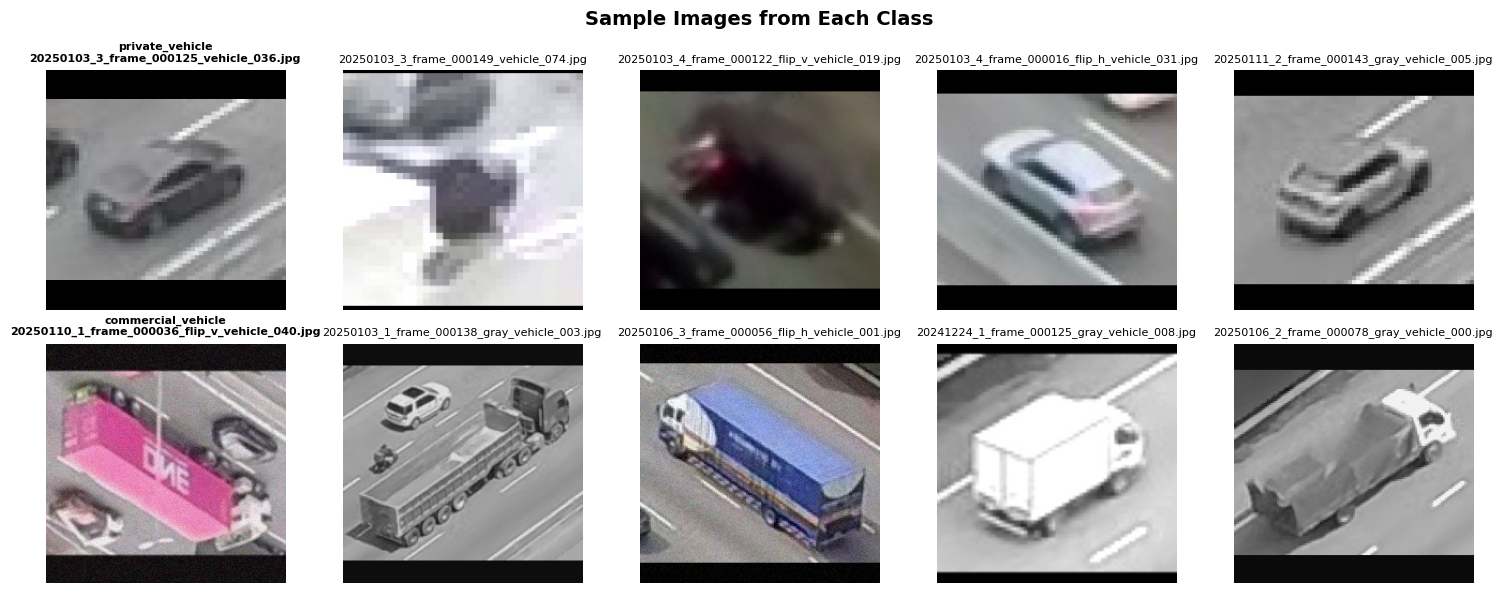

In [7]:
# Display sample images from each class
def show_sample_images(n_samples=5):
    """
    Display sample images from each class in the training set.
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
    
    for idx, (class_id, class_name) in enumerate(CLASS_NAMES.items()):
        class_dir = OUTPUT_DIR / 'train' / class_name
        image_files = list(class_dir.glob('*.jpg'))
        
        if len(image_files) == 0:
            print(f"No images found for class: {class_name}")
            continue
        
        # Randomly sample images
        sample_files = random.sample(image_files, min(n_samples, len(image_files)))
        
        for i, img_path in enumerate(sample_files):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[idx, i].imshow(img_rgb)
            axes[idx, i].axis('off')
            if i == 0:
                axes[idx, i].set_title(f"{class_name}\n{img_path.name}", 
                                      fontsize=8, fontweight='bold')
            else:
                axes[idx, i].set_title(img_path.name, fontsize=8)
    
    plt.tight_layout()
    
    # Save figure
    samples_path = OUTPUT_DIR / 'sample_images.png'
    plt.savefig(samples_path, dpi=300, bbox_inches='tight')
    print(f"Sample images saved to: {samples_path}")
    
    plt.show()

show_sample_images(n_samples=5)

# Task 2: Classification Model Implementation

In [8]:
# Should contain train/val/test
for split in ["train", "val", "test"]:
    p = OUTPUT_DIR / split
    assert p.exists(), f"Missing split folder: {p}"

## 1) Data Loading & Preprocessing pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

LABEL_MODE = "binary"
CLASS_NAMES = sorted([p.name for p in (OUTPUT_DIR/"train").iterdir() if p.is_dir()])
print("Class names:", CLASS_NAMES)

def make_datasets(img_size, batch_size=16):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        OUTPUT_DIR/"train",
        labels="inferred",
        label_mode=LABEL_MODE,
        class_names=CLASS_NAMES,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        OUTPUT_DIR/"val",
        labels="inferred",
        label_mode=LABEL_MODE,
        class_names=CLASS_NAMES,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        OUTPUT_DIR/"test",
        labels="inferred",
        label_mode=LABEL_MODE,
        class_names=CLASS_NAMES,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds   = val_ds.prefetch(AUTOTUNE)
    test_ds  = test_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, test_ds

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="augmentation",
)

Class names: ['commercial_vehicle', 'private_vehicle']


## 2) Model factory (EfficientNet)

Two transfer-learning strategies:
- **Frozen**: freeze the whole backbone, train only the classification head.
- **Fine-tune**: unfreeze last *N* layers after the head stabilizes, using a smaller learning rate.

In [10]:
from tensorflow.keras.applications import EfficientNetB0

def build_model(
    img_size=(224, 224),
    num_classes=1,
    dropout=0.2,
    base_trainable=False,
    fine_tune_at=None,
    freeze_batchnorm=True,
):
    input_shape = (*img_size, 3)

    # Backbone (EfficientNetB0 only)
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)

    # Transfer learning strategy (same idea as your ipynb)
    base.trainable = base_trainable
    if base_trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False
        for layer in base.layers[fine_tune_at:]:
            layer.trainable = True

    if freeze_batchnorm:
        for layer in base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    # Head (same as your ipynb)
    inputs = keras.Input(shape=input_shape, name="image")
    x = inputs
    x = data_augmentation(x)  # only active during training

    # Important: when base is frozen, keep BN in inference mode
    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="sigmoid", name="classifier")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetB0_tl")
    return model

## 3) Training utilities (consistent metrics, callbacks, evaluation)

In [11]:
def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.BinaryAccuracy(name="acc")]
    )
    return model

def make_callbacks(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(run_dir / "best.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

def evaluate_model(model, test_ds):
    results = model.evaluate(test_ds, verbose=0)
    return dict(zip(model.metrics_names, results))

## 4) Experiment configs

In [12]:
EXPERIMENTS = {
    "EfficientNetB0_frozen": dict(
        img_size=(128, 128),
        batch_size=16,
        base_trainable=False,
        fine_tune_at=None,
        lr_head=1e-3,
        lr_ft=1e-5,
    ),
    "EfficientNetB0_finetune": dict(
        img_size=(128, 128),
        batch_size=16,
        base_trainable=True,
        fine_tune_at=200,   # same as your original safe default
        lr_head=1e-3,
        lr_ft=1e-5,
    ),
}

## 5) Run one experiment (head training + optional fine-tune)

In [13]:
from datetime import datetime

def run_experiment(exp_name, epochs_head=10, epochs_ft=10, dropout=0.2):
    cfg = EXPERIMENTS[exp_name]
    img_size = cfg["img_size"]
    batch_size = cfg["batch_size"]

    run_dir = Path("runs") / exp_name
    run_dir.mkdir(parents=True, exist_ok=True)

    train_ds, val_ds, test_ds = make_datasets(img_size=img_size, batch_size=batch_size)

    # --------- Phase 1: frozen backbone (head training) ---------
    model = build_model(
        img_size=img_size,
        dropout=dropout,
        base_trainable=False,
        fine_tune_at=None,
    )
    compile_model(model, lr=cfg["lr_head"])

    print(model.name)
    model.summary()

    callbacks = make_callbacks(run_dir)

    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_head,
        callbacks=callbacks,
        verbose=1,
    )

    # --------- Phase 2: fine-tune ---------
    history_ft = None

    do_finetune = (
        epochs_ft is not None and epochs_ft > 0
        and cfg.get("fine_tune_at") is not None
    )

    if do_finetune:
        ft_model = build_model(
            img_size=img_size,
            dropout=dropout,
            base_trainable=True,
            fine_tune_at=cfg["fine_tune_at"],
        )

        # Load head weights from phase 1
        ft_model.set_weights(model.get_weights())

        compile_model(ft_model, lr=cfg["lr_ft"])

        callbacks = make_callbacks(run_dir / "finetune")
        history_ft = ft_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs_ft,
            callbacks=callbacks,
            verbose=1,
        )
        model = ft_model

    # Evaluate
    metrics = evaluate_model(model, test_ds)
    print("Test metrics:", metrics)

    # Save final model
    model.save(run_dir / "final.keras")

    return model, history_head, history_ft, metrics


# Task 3: Model Training

In [14]:
TRAIN_PLAN = [
    dict(
        name="EfficientNetB0_main",
        exp="EfficientNetB0_frozen",
        epochs_head=3,
        epochs_ft=0,
        dropout=0.3,
    )
]

In [15]:
all_results = []

for cfg in TRAIN_PLAN:
    print("\n==============================")
    print("Running:", cfg["name"])
    print(cfg)
    print("==============================")

    model, h1, h2, metrics = run_experiment(
        cfg["exp"],
        epochs_head=cfg["epochs_head"],
        epochs_ft=cfg["epochs_ft"],
        dropout=cfg["dropout"],
    )

    # Case 1: metrics returned as list/tuple (rare for your current code)
    if isinstance(metrics, (list, tuple)) and len(metrics) >= 2:
        loss, acc = metrics[0], metrics[1]
        row = {"model": cfg["name"], "loss": float(loss), "acc": float(acc)}

    # Case 2: metrics returned as dict (your evaluate_model returns dict)
    else:
        # Normalize possible metric names to 'acc'
        acc_value = None
        for k in ["acc", "binary_accuracy", "accuracy"]:
            if k in metrics:
                acc_value = metrics[k]
                break

        row = {
            "model": cfg["name"],
            "loss": float(metrics.get("loss", np.nan)),
            "acc": float(acc_value) if acc_value is not None else np.nan,
            **{k: float(v) for k, v in metrics.items() if k not in ["loss", "acc"]}
        }

    all_results.append(row)


Running: EfficientNetB0_main
{'name': 'EfficientNetB0_main', 'exp': 'EfficientNetB0_frozen', 'epochs_head': 3, 'epochs_ft': 0, 'dropout': 0.3}
Found 132776 files belonging to 2 classes.
Found 40748 files belonging to 2 classes.
Found 18384 files belonging to 2 classes.
EfficientNetB0_tl


Model: "EfficientNetB0_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/3
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - acc: 0.9523 - loss: 0.1392   
Epoch 1: val_loss improved from inf to 0.09303, saving model to runs\EfficientNetB0_frozen\best.keras
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 3207s 384ms/step - acc: 0.9523 - loss: 0.1392 - val_acc: 0.9692 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 2/3
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - acc: 0.9623 - loss: 0.1102   
Epoch 2: val_loss improved from 0.09303 to 0.09095, saving model to runs\EfficientNetB0_frozen\best.keras
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 3361s 405ms/step - acc: 0.9623 - loss: 0.1102 - val_acc: 0.9697 - val_loss: 0.0910 - learning_rate: 0.0010
Epoch 3/3
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - acc: 0.9637 - loss: 0.1076   
Epoch 3: val_loss did not improve from 0.09095

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8299/8299 ━━━━━━━━━━━━━━━━━━━━ 3278s 395ms/step - acc: 0.9637 - loss: 0.1076 - val_acc: 0.9688 - val_loss: 0.0932 - learning_rate: 

In [16]:
df_results = pd.DataFrame(all_results)

print("Columns in df_results:", df_results.columns.tolist())

# Pick the best available accuracy column
for col in ["acc", "binary_accuracy", "accuracy", "compile_metrics"]:
    if col in df_results.columns:
        metric_col = col
        break
else:
    metric_col = None

if metric_col is not None:
    df_results = df_results.sort_values(by=metric_col, ascending=False)

df_results

Columns in df_results: ['model', 'loss', 'acc', 'compile_metrics']


,model,loss,acc,compile_metrics
0,EfficientNetB0_main,0.091084,NaN,0.968668


# Task 4: Evaluation and sample outputs

In [17]:
BEST_MODEL_PATH = Path("runs/EfficientNetB0_frozen/best.keras")  
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Loaded:", BEST_MODEL_PATH.resolve())

Loaded: C:\Users\ASUS\Desktop\Afiq\Study\VIP\Project\runs\EfficientNetB0_frozen\best.keras


In [19]:
IMG_SIZE = (128, 128)   # MUST match what you used in make_datasets during training
BATCH_SIZE = 16         # match training

train_ds, val_ds, test_ds = make_datasets(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

Found 132776 files belonging to 2 classes.
Found 40748 files belonging to 2 classes.
Found 18384 files belonging to 2 classes.


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

test_scores = best_model.evaluate(test_ds, verbose=1)
print("Test metrics:", dict(zip(best_model.metrics_names, test_scores)))

# Collect true labels + predicted probs on test set
y_true, y_prob = [], []

for x_batch, y_batch in test_ds:
    probs = best_model.predict(x_batch, verbose=0).reshape(-1)
    y_prob.extend(probs.tolist())
    y_true.extend(y_batch.numpy().reshape(-1).tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

1149/1149 ━━━━━━━━━━━━━━━━━━━━ 362s 315ms/step - acc: 0.9216 - loss: 0.2163
Test metrics: {'loss': 0.09108403325080872, 'compile_metrics': 0.9686684012413025}
Confusion Matrix:
 [[ 1712   424]
 [  152 16096]]

Classification Report:
                    precision    recall  f1-score   support

commercial_vehicle     0.9185    0.8015    0.8560      2136
   private_vehicle     0.9743    0.9906    0.9824     16248

          accuracy                         0.9687     18384
         macro avg     0.9464    0.8961    0.9192     18384
      weighted avg     0.9678    0.9687    0.9677     18384



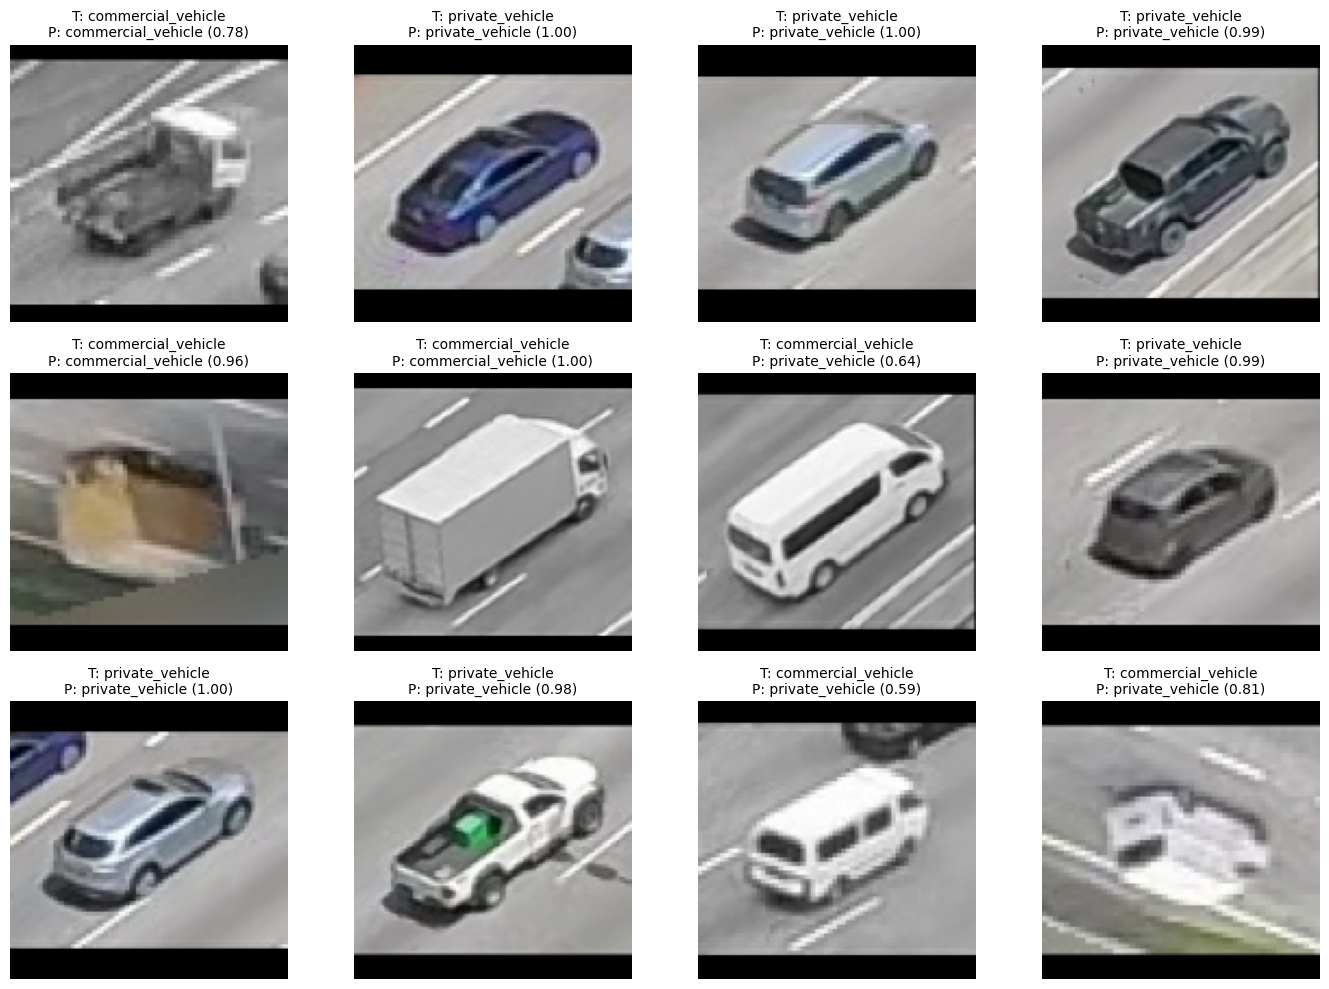

In [35]:
import matplotlib.pyplot as plt
import math
import numpy as np

def show_random_balanced_predictions(
    model,
    dataset,
    class_names,
    n=12,
    threshold=0.5
):
    plt.figure(figsize=(14, 10))

    # Collect samples by class
    samples = {0: [], 1: []}

    for images, labels in dataset.shuffle(2000):
        probs = model.predict(images, verbose=0).reshape(-1)
        preds = (probs >= threshold).astype(int)

        for i in range(images.shape[0]):
            true_i = int(labels[i].numpy().item())
            pred_i = int(preds[i])
            conf = float(probs[i]) if pred_i == 1 else float(1.0 - probs[i])

            if len(samples[true_i]) < n // 2:
                samples[true_i].append(
                    (images[i].numpy(), true_i, pred_i, conf)
                )

        if all(len(v) >= n // 2 for v in samples.values()):
            break

    # Merge and shuffle samples
    all_samples = samples[0] + samples[1]
    np.random.shuffle(all_samples)

    rows = int(math.ceil(n / 4))

    for idx, (img, true_i, pred_i, conf) in enumerate(all_samples[:n]):
        plt.subplot(rows, 4, idx + 1)
        plt.imshow(img.astype("uint8"))
        plt.axis("off")
        plt.title(
            f"T: {class_names[true_i]}\n"
            f"P: {class_names[pred_i]} ({conf:.2f})",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

show_random_balanced_predictions(
    best_model,
    test_ds,
    CLASS_NAMES,
    n=12
)